In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
from google.colab import files
uploaded = files.upload()

Saving Fraud Detection Dataset.csv to Fraud Detection Dataset.csv


In [3]:
df = pd.read_csv("Fraud Detection Dataset.csv")
print(df.shape)
df.head()

(51000, 12)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [4]:
df.columns.tolist()
list(df)

['Transaction_ID',
 'User_ID',
 'Transaction_Amount',
 'Transaction_Type',
 'Time_of_Transaction',
 'Device_Used',
 'Location',
 'Previous_Fraudulent_Transactions',
 'Account_Age',
 'Number_of_Transactions_Last_24H',
 'Payment_Method',
 'Fraudulent']

In [5]:
df=df.dropna()

In [6]:
missing_percent = df.isnull().mean()*100

print(missing_percent)

Transaction_ID                      0.0
User_ID                             0.0
Transaction_Amount                  0.0
Transaction_Type                    0.0
Time_of_Transaction                 0.0
Device_Used                         0.0
Location                            0.0
Previous_Fraudulent_Transactions    0.0
Account_Age                         0.0
Number_of_Transactions_Last_24H     0.0
Payment_Method                      0.0
Fraudulent                          0.0
dtype: float64


In [7]:
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 688


In [8]:
column_duplicates = {col: df[col].duplicated().sum() for col in df.columns}
duplicate_df = pd.DataFrame(list(column_duplicates.items()), columns=['Column', 'Duplicate_Count'])
print(duplicate_df.to_string(index=False))

                          Column  Duplicate_Count
                  Transaction_ID              787
                         User_ID            35583
              Transaction_Amount             2667
                Transaction_Type            39578
             Time_of_Transaction            39559
                     Device_Used            39579
                        Location            39575
Previous_Fraudulent_Transactions            39578
                     Account_Age            39464
 Number_of_Transactions_Last_24H            39569
                  Payment_Method            39578
                      Fraudulent            39581


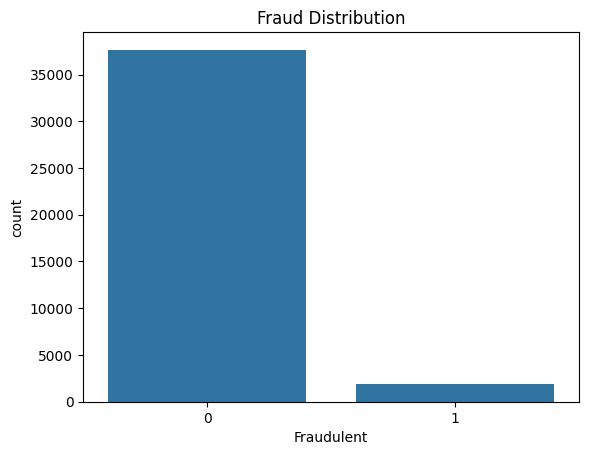

In [9]:
sns.countplot(x="Fraudulent", data=df)

plt.title("Fraud Distribution")

plt.show()

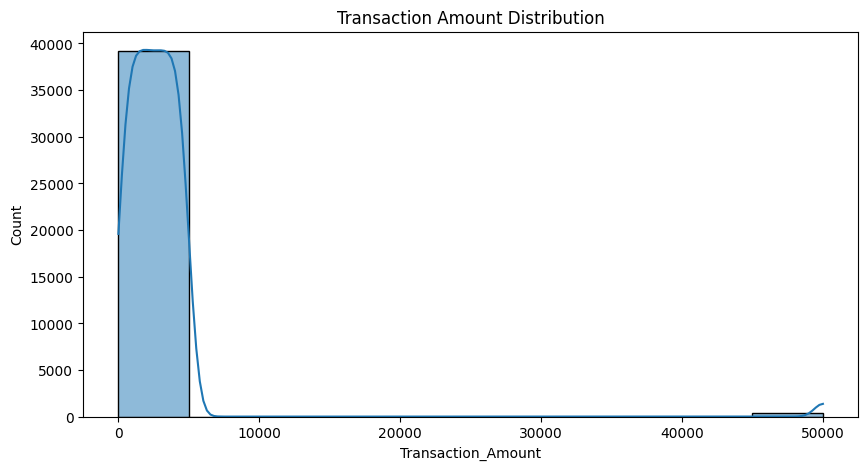

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Transaction_Amount"],
    bins=10,
    kde=True
)

plt.title("Transaction Amount Distribution")

plt.show()

Percentage Breakdown (%):
Fraudulent              0         1
Payment_Method                     
Credit Card     95.142042  4.857958
Debit Card      95.261353  4.738647
Invalid Method  95.447154  4.552846
Net Banking     95.012101  4.987899
UPI             95.019471  4.980529


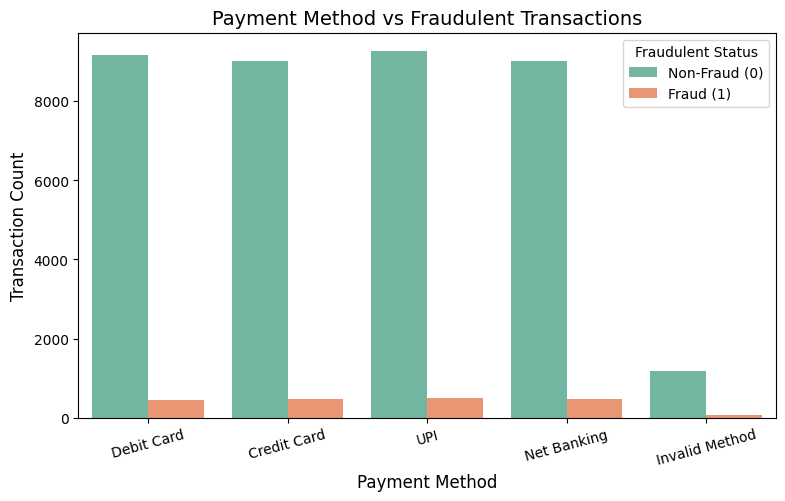

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a cross-tabulation of Payment Method vs Fraudulent status
payment_fraud_ct = pd.crosstab(df["Payment_Method"], df["Fraudulent"], normalize='index') * 100
print("Percentage Breakdown (%):")
print(payment_fraud_ct)

# Plotting the relationship graph
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="Payment_Method", hue="Fraudulent", palette="Set2")
plt.title("Payment Method vs Fraudulent Transactions", fontsize=14)
plt.xlabel("Payment Method", fontsize=12)
plt.ylabel("Transaction Count", fontsize=12)
plt.legend(title="Fraudulent Status", labels=["Non-Fraud (0)", "Fraud (1)"])
plt.xticks(rotation=15)
plt.show()

<Axes: >

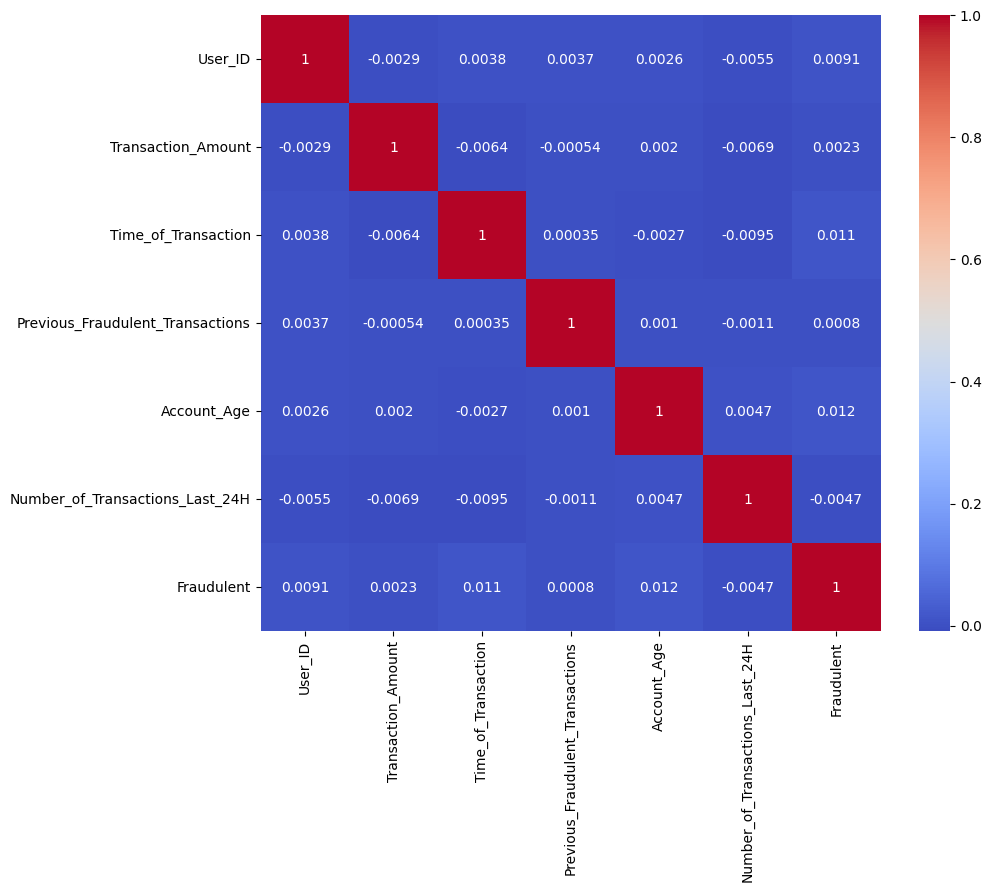

In [12]:
numeric = df.select_dtypes(include="number")

plt.figure(figsize=(10,8))

sns.heatmap(

numeric.corr(),

annot=True,

cmap="coolwarm"

)

# Outlier

Text(0.5, 1.0, 'Transaction Amount Boxplot')

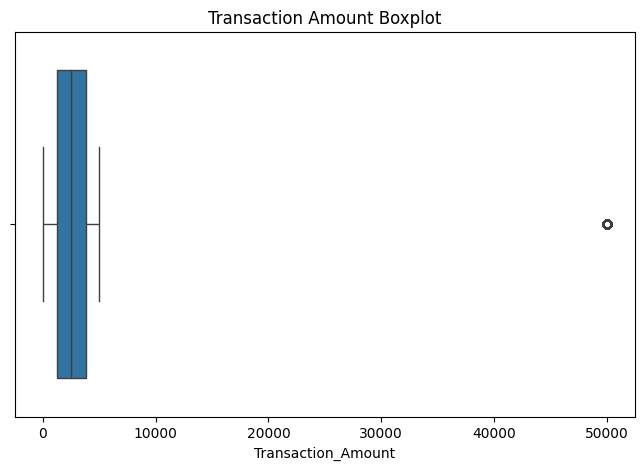

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Transaction_Amount"]
)

plt.title("Transaction Amount Boxplot")

In [14]:
Q1 = df["Transaction_Amount"].quantile(0.25)

Q3 = df["Transaction_Amount"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR


outliers = df[
    (df["Transaction_Amount"] < lower) |
    (df["Transaction_Amount"] > upper)
]

#Lower_outlier= df[df["Transaction_Amount"] < lower]

#Lower_outlier.head()

#upper_outlier= df[df["Transaction_Amount"] < upper]

#upper_outlier.head()
#upper_outlier.shape
#Lower_outlier.shape
print(outliers.shape)
#outliers.head()

(416, 12)


Q1: 5.0, Q3: 17.0, IQR: 12.0
Lower Bound: -13.0, Upper Bound: 35.0
Number of Outliers in Time_of_Transaction: 0


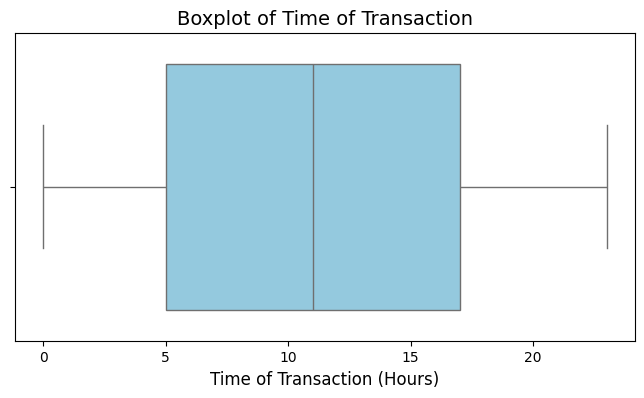

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Q1, Q3, and IQR for Time_of_Transaction
Q1 = df["Time_of_Transaction"].quantile(0.25)
Q3 = df["Time_of_Transaction"].quantile(0.75)
IQR = Q3 - Q1

# 2. Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Filter outliers
time_outliers = df[(df["Time_of_Transaction"] < lower_bound) | (df["Time_of_Transaction"] > upper_bound)]

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
print(f"Number of Outliers in Time_of_Transaction: {len(time_outliers)}")

# 4. Create Boxplot Graph
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["Time_of_Transaction"], color="skyblue")
plt.title("Boxplot of Time of Transaction", fontsize=14)
plt.xlabel("Time of Transaction (Hours)", fontsize=12)
plt.show()

In [ ]:
Task 3: Identify Uncommon/Common Value/s

In [16]:
# Task 3: Identify Uncommon/Common Values
categorical_columns = ["Transaction_Type", "Device_Used", "Location", "Payment_Method"]

for col in categorical_columns:
    print(f"=== Value Counts for: {col} ===")
    counts = df[col].value_counts()
    print(counts)
    print(f"Most Common: '{counts.idxmax()}' ({counts.max()} occurrences)")
    print(f"Uncommon / Rare: '{counts.idxmin()}' ({counts.min()} occurrences)\n")

=== Value Counts for: Transaction_Type ===
Transaction_Type
Bank Transfer      8012
Bill Payment       7963
ATM Withdrawal     7890
POS Payment        7871
Online Purchase    7847
Name: count, dtype: int64
Most Common: 'Bank Transfer' (8012 occurrences)
Uncommon / Rare: 'Online Purchase' (7847 occurrences)

=== Value Counts for: Device_Used ===
Device_Used
Desktop           12835
Tablet            12777
Mobile            12734
Unknown Device     1237
Name: count, dtype: int64
Most Common: 'Desktop' (12835 occurrences)
Uncommon / Rare: 'Unknown Device' (1237 occurrences)

=== Value Counts for: Location ===
Location
Boston           5045
Seattle          4997
New York         4963
Los Angeles      4945
Chicago          4933
San Francisco    4928
Miami            4895
Houston          4877
Name: count, dtype: int64
Most Common: 'Boston' (5045 occurrences)
Uncommon / Rare: 'Houston' (4877 occurrences)

=== Value Counts for: Payment_Method ===
Payment_Method
UPI               9758
Debit Car

In [21]:
# 1. Define a different feature set for anomaly detection
features = [
    "Transaction_Amount",
    "Previous_Fraudulent_Transactions",
    "Account_Age",
    "Number_of_Transactions_Last_24H"
]

X = df[features]

In [22]:
# 2. Scale the features using StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
# 3. Apply DBSCAN clustering to detect noise/anomalies (labeled as -1)
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.8,
    min_samples=15
)

labels = dbscan.fit_predict(X_scaled)
df["Cluster"] = labels

# 4. Filter and display anomalies (Cluster == -1)
suspicious = df[df["Cluster"] == -1]

print(f"Total number of anomalies detected: {len(suspicious)}")
print(df["Cluster"].value_counts())
display(suspicious.head())

Total number of anomalies detected: 8
Cluster
 0    39167
 1      408
-1        8
Name: count, dtype: int64


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent,Cluster
317,T318,4681,49997.8,Bill Payment,0.0,Mobile,Houston,4,4,14,Credit Card,0,-1
8146,T8147,1640,49997.8,Bill Payment,17.0,Tablet,Los Angeles,4,7,14,Debit Card,1,-1
15441,T15442,4030,49997.8,Bank Transfer,20.0,Desktop,Seattle,0,5,3,Credit Card,0,-1
19824,T19825,2206,49997.8,Online Purchase,14.0,Mobile,Miami,1,2,1,Credit Card,0,-1
22058,T22059,3612,49997.8,Bank Transfer,20.0,Tablet,New York,1,119,1,Net Banking,0,-1


In [24]:
suspicious = df[df["Cluster"] == -1]

print(suspicious.head())

      Transaction_ID  User_ID  Transaction_Amount Transaction_Type  \
317             T318     4681             49997.8     Bill Payment   
8146           T8147     1640             49997.8     Bill Payment   
15441         T15442     4030             49997.8    Bank Transfer   
19824         T19825     2206             49997.8  Online Purchase   
22058         T22059     3612             49997.8    Bank Transfer   

       Time_of_Transaction Device_Used     Location  \
317                    0.0      Mobile      Houston   
8146                  17.0      Tablet  Los Angeles   
15441                 20.0     Desktop      Seattle   
19824                 14.0      Mobile        Miami   
22058                 20.0      Tablet     New York   

       Previous_Fraudulent_Transactions  Account_Age  \
317                                   4            4   
8146                                  4            7   
15441                                 0            5   
19824                   

### Task 5: Cluster Graph (any two attributes)

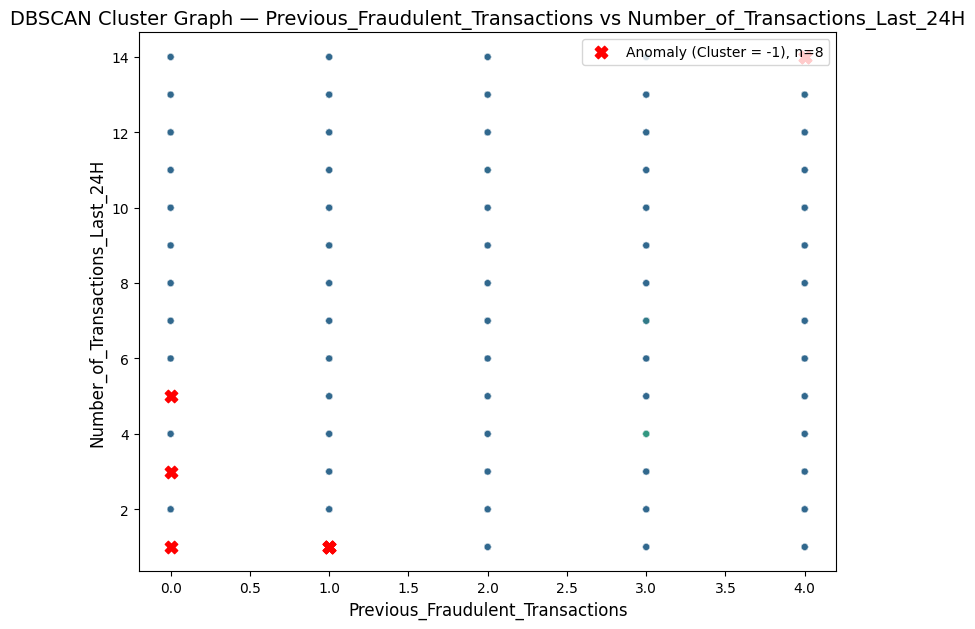

In [30]:
# Select another alternative pair of attributes
x_attr = "Previous_Fraudulent_Transactions"
y_attr = "Number_of_Transactions_Last_24H"

# Separate normal points from noise/anomalies (-1)
non_noise = df[df["Cluster"] != -1]
noise = df[df["Cluster"] == -1]

# Take a random sample for clean visualization
sample_size = min(3000, len(non_noise))
plot_sample = non_noise.sample(n=sample_size, random_state=42)

# Create the scatter plot
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=plot_sample,
    x=x_attr, y=y_attr,
    hue="Cluster",
    palette="viridis",
    alpha=0.6, s=25,
    legend=False
)

plt.scatter(
    noise[x_attr], noise[y_attr],
    c="red", marker="X", s=80,
    label=f"Anomaly (Cluster = -1), n={len(noise)}"
)

plt.xlabel(x_attr, fontsize=12)
plt.ylabel(y_attr, fontsize=12)
plt.title(f"DBSCAN Cluster Graph — {x_attr} vs {y_attr}", fontsize=14)
plt.legend(loc="upper right")
plt.show()